In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('./all_catapult_data_7_Jul_25.csv')

In [2]:
# strip whitespace, replace spaces/slashes with underscores
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'\s+', '_', regex=True)
      .str.replace(r'[\/\(\)\-]', '', regex=True)
)

def clean_text(s):
    if pd.isnull(s):
        return s
    s = s.strip()                        # Remove leading/trailing whitespace
    s = re.sub(r'\s+', ' ', s)          # Replace multiple spaces with single
    s = s.lower()                       # Convert to lowercase (optional)
    s = s.replace('_', ' ')             # Replace underscores with space
    s = s.title()                       # Convert to Title Case
    return s

# Apply cleaning to each text column
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)

#convert date to datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

#select only the 'Game' tag, exclude training etc 
df = df[df['tags'] == 'Game']
df = df.drop('tags', axis=1)

df['duration'] = df['duration'] / 60 #convert duration to minutes for easy comparison

#select only the first and second halves ; ensure proper naming of splits
df = df[((df['split_name'] == '1St.Half') | (df['split_name'] == '2Nd.Half'))]
df['split_name'] = df['split_name'].str.replace('1St.Half', '1st Half')
df['split_name'] = df['split_name'].str.replace('2Nd.Half', '2nd Half')



In [3]:
# Select only session_title entries matching the pattern: 'Wmd1-Kampala Queens Fc-Olila HS WFC-Home-League-Win' ( standard naming convention)
pattern = r'^Wmd\d+-[A-Za-z ]+-[A-Za-z ]+-[A-Za-z]+-[A-Za-z]+-[A-Za-z]+$'
df = df[df['session_title'].str.match(pattern, na=False)]

In [4]:
#split the player name and session title columns into columns 
df[['match_day', 'club_for', 'club_against', 'location', 'league', 'result']] = df['session_title'].str.split('-', n=5, expand=True)
df[['p_name', 'player_club_', 'player_position']] = df['player_name'].str.split('-', n=2, expand=True)
df = df.drop(['session_title', 'player_name'], axis=1)

# Apply cleaning to each text column again to catch any new text data
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)

In [5]:
#ensure all entries have the proper 'league' value; fix any that may be interchanged with location or result 
mask = df['league'] != 'League'
df.loc[mask, ['location', 'league']] = df.loc[mask, ['league', 'location']].values
df.loc[df['league'] == 'Home', 'league'] = 'League'
df = df.drop('league', axis=1)

In [6]:
df.loc[df['result'] == 'Dra', 'result'] = 'Draw'
df.loc[df['result'] == 'Iwin', 'result'] = 'Win'

In [7]:
# list of standard UPL club names

standard_clubs = [
    'Kampala Queens FC','She Maroons FC','Makerere University WFC',
    'Uganda Martyrs Lubaga WFC','Kawempe Muslim LFC','Wakiso Hill WFC','Olila HS WFC',
    'Rines SS WFC','Amus College WFC','She Corporates FC','Lady Doves FC','FC Tooro Queens'
]

def normalize_name(name):
    # Remove spaces, punctuation, and 'fc', 'sc', etc.
    name = name.lower()
    name = re.sub(r'[^a-z]', '', name)  # keep only letters
    name = name.replace('fc', '').replace('sc', '')
    return name

def best_match(name, club_list, min_score=0.6):
    name_clean = name.strip().lower().replace('.', '')
    norm_name = normalize_name(name_clean)
    # 1. Normalized exact match
    for club in club_list:
        if norm_name == normalize_name(club):
            return club
    # 2. Normalized substring match
    for club in club_list:
        club_norm = normalize_name(club)
        if norm_name in club_norm or club_norm in norm_name:
            return club
    # 3. Token overlap (as before)
    name_tokens = set(name_clean.split())
    best = None
    best_score = 0
    for club in club_list:
        club_tokens = set(club.strip().lower().replace('.', '').split())
        score = len(name_tokens & club_tokens) / max(len(club_tokens), 1)
        if score > best_score:
            best = club
            best_score = score
    return best if best_score >= min_score else name

# Apply to all columns with club names 
for col in ['club_for', 'club_against', 'player_club_']:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(lambda x: best_match(x, standard_clubs))


In [8]:
for col in ['club_for', 'club_against', 'player_club_']:
    if col in df.columns:
        df[col] = df[col].replace('Uganda Martyrs Hs', 'Uganda Martyrs Lubaga WFC')
        df[col] = df[col].replace("Uganda Martyr'S Hs", 'Uganda Martyrs Lubaga WFC')
        df[col] = df[col].replace("Uganda Martrys", 'Uganda Martyrs Lubaga WFC')
        df[col] = df[col].replace('She Corporate Wfc', 'She Corporates FC')
        df[col] = df[col].replace('Olila High School', 'Olila HS WFC')
        df[col] = df[col].replace('Wakiso Hills', 'Wakiso Hill WFC')
        df[col] = df[col].replace('She Coperates', 'She Corporates FC')

In [9]:
df['player_position'] = df['player_position'].replace('Muslim-Am', 'Am')
df['player_position'] = df['player_position'].replace('F', 'Fwd')

In [10]:
df['player_position'] = df['player_position'].str.lower()

In [11]:
df['general_position'] = df['player_position'].map({
            'gk': 'goalkeepers', 'df': 'defenders', 'mf': 'midfielders', 'am': 'midfielders',
            'fw': 'forwards', 'rb': 'defenders', 'cb': 'defenders', 'lb': 'defenders',
            'rw': 'forwards', 'lw': 'forwards', 'cm': 'midfielders', 'dm': 'midfielders',
            'cd':'defenders','fwd':'forwards','dmc':'midfielders','amc':'midfielders','dc':'defenders',
            'cf':'forwards','mc':'midfielders','lcb':'defenders','md':'midfielders'
        })

In [12]:
df = df[df['player_position'] != 'gk']

In [13]:
# Apply cleaning to each text column again to catch any new text data
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)
    df[col] = df[col].astype('category')

In [14]:
zero_frac = (df == 0).mean().sort_values(ascending=False)
sparse = zero_frac[zero_frac > 0.95]
sparse.index.tolist()

# #drop these columns(more than 95% of their values are 0) from the dataset
df = df.drop(columns=sparse.index.tolist())

In [15]:
df.shape

(4489, 93)

In [16]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest

In [17]:
#Identify the columns with missing data
missing_counts = df.isnull().sum().sort_values(ascending=False)
print(f'Number of columns with missing data: {len(missing_counts[missing_counts > 0])}')

# Check for duplicate rows in the dataset
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

df = df.drop(columns=['split_start_time', 'split_end_time'])

Number of columns with missing data: 0
Number of duplicate rows: 0


In [18]:
def describe_numeric_columns(df):
    n_desc = df[num_cols].describe().T
    n_desc = n_desc.drop(['25%', '75%'], axis=1)
    n_desc = n_desc.rename(columns={'50%': 'median'})
    display(n_desc.T[num_cols].T)

def describe_categorical_columns(df):
    cat_vars = df.select_dtypes(include='category').columns
    c_desc = df[cat_vars].describe().T
    c_desc['%age'] = c_desc['freq'] / len(df) * 100
    display(c_desc)
    
def plot_numerical_distributions(df):
    plt.figure(figsize=(16, 8))
    for i, col in enumerate(num_cols):
        plt.subplot(4, 4, i + 1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()



In [19]:
half2_df = df[df['split_name'] == '2Nd Half']
half2_df = half2_df.drop('split_name', axis=1)

half1_df = df[df['split_name'] == '1St Half']
half1_df = half1_df.drop('split_name', axis=1)

In [20]:
merge_keys = ['p_name', 'club_for', 'club_against', 'player_club_','match_day','general_position','player_position','result','location']

half1_df_rn = half1_df.rename(columns=lambda x: x + '_H1' if x not in merge_keys else x)
half2_df_rn = half2_df.rename(columns=lambda x: x + '_H2' if x not in merge_keys else x)

df_merged = pd.merge(half1_df_rn, half2_df_rn, on=merge_keys, how='outer')


df_combined = df_merged[merge_keys].copy()

# Numerical Variables of high interest - consider sum
for col in num_cols:
    if col not in ['top_speed_kmh', 'distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Use .fillna(0) to handle missing halves
        df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)

# Top Speed - consider max
df_combined['top_speed_kmh'] = df_merged[['top_speed_kmh_H1', 'top_speed_kmh_H2']].max(axis=1)
# Max Acceleration - consider max
df_combined['max_acceleration_mss'] = df_merged[['max_acceleration_mss_H1', 'max_acceleration_mss_H2']].max(axis=1)
# Max Deceleration - consider max
df_combined['max_deceleration_mss'] = df_merged[['max_deceleration_mss_H1', 'max_deceleration_mss_H2']].max(axis=1)

# distance per minute - recalculate from sum
df_combined['distance_per_min_mmin'] = (df_combined['distance_km'] *1000) / df_combined['duration']

#all other numerical variables - consider sum
# Columns in numeric_cols that are not in num_cols
for col in numeric_cols.difference(num_cols):
    if col not in merge_keys:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Only sum if both columns exist in df_merged
        if h1 in df_merged.columns and h2 in df_merged.columns:
            df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)


In [21]:
match_df = df_combined

In [22]:
# Thresholds
DIST_THRESH = 2   # players should cover at least 2km in a session to count
DURATION_THRESH = 60  # players should be active for at least 60 minutes in a session    

# Extend your active_session flag:
match_df['active_session'] = (
    (match_df['distance_km']    >= DIST_THRESH)  
    & (match_df['duration']  >= DURATION_THRESH)   
)

match_df = match_df[match_df['active_session'] == True]  # Filter main df for active sessions
match_df = match_df.drop('active_session', axis=1)  # Drop the active_session column after filtering

In [23]:
#Calculating Outlier Bounds
q1 = match_df['distance_km'].quantile(0.25)
q3 = match_df['distance_km'].quantile(0.75)
iqr = q3 - q1
lower_bound_dist = q1 - 1.5 * iqr
upper_bound_dist = q3 + 1.5 * iqr

q1 = match_df['duration'].quantile(0.25)
q3 = match_df['duration'].quantile(0.75)
iqr = q3 - q1
lower_bound_dur = q1 - 1.5 * iqr
upper_bound_dur = q3 + 1.5 * iqr

#filter out outliers based on the calculated bounds
match_df = match_df[
    (match_df['distance_km'] >= lower_bound_dist) & (match_df['distance_km'] <= upper_bound_dist) &
    (match_df['duration'] >= lower_bound_dur) & (match_df['duration'] <= upper_bound_dur)
]

In [24]:
describe_categorical_columns(match_df)

,count,unique,top,freq,%age
p_name,1621,188,Joweria Babirye,19,1.172116
club_for,1621,11,She Maroons Fc,229,14.127082
club_against,1621,12,Lady Doves Fc,158,9.74707
player_club_,1621,11,She Maroons Fc,229,14.127082
match_day,1621,22,Wmd7,112,6.909315
general_position,1621,3,Defenders,632,38.988279
player_position,1621,17,Fw,311,19.185688
result,1621,3,Win,595,36.705737
location,1621,2,Home,887,54.719309


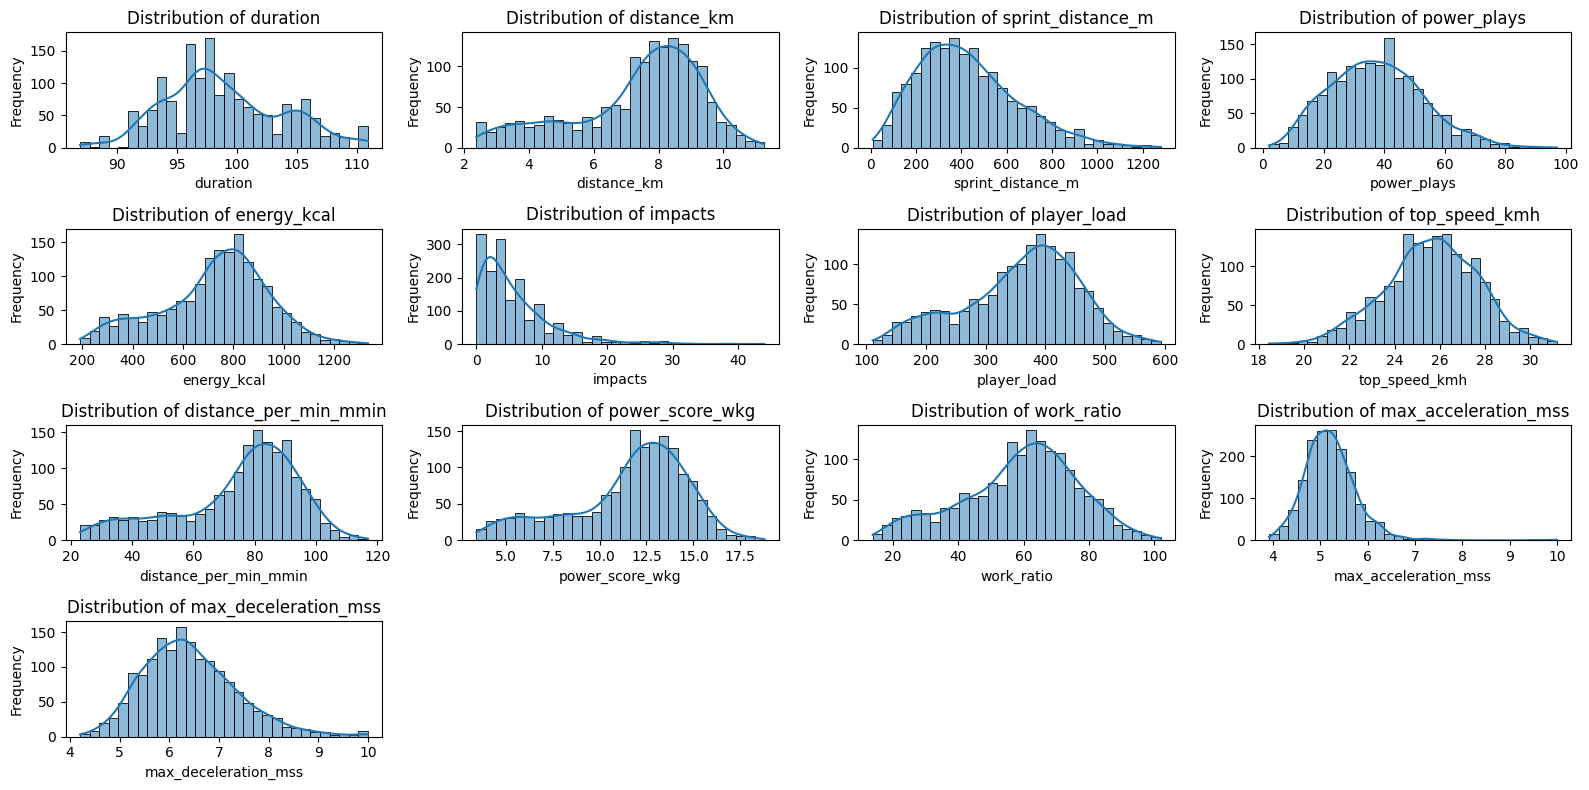

In [25]:
plot_numerical_distributions(match_df)

In [26]:
describe_numeric_columns(match_df)

,count,mean,std,min,median,max
duration,1621.0,98.851851,4.873287,86.900000,97.900000,110.933333
distance_km,1621.0,7.365603,1.973326,2.381800,7.842700,11.261000
sprint_distance_m,1621.0,426.628563,219.975238,8.746000,394.341000,1279.411000
power_plays,1621.0,37.491055,15.251576,2.000000,37.000000,97.000000
energy_kcal,1621.0,727.592689,208.734992,190.974000,756.408600,1334.901400
impacts,1621.0,5.664405,5.564073,0.000000,4.000000,44.000000
player_load,1621.0,360.131328,94.296341,110.641100,375.910700,593.191200
top_speed_kmh,1621.0,25.609207,2.012019,18.448100,25.704200,31.168200
distance_per_min_mmin,1621.0,74.571150,19.871926,22.977693,79.647157,116.958686
power_score_wkg,1621.0,11.564177,3.129363,3.429800,12.270700,18.785700


In [27]:
match_df['max_acceleration_mss'].describe()

count    1621.000000
mean        5.216721
std         0.562937
min         3.918600
25%         4.856600
50%         5.168900
75%         5.507100
max        10.000000
Name: max_acceleration_mss, dtype: float64

In [ ]:
# Save the cleaned and processed DataFrame to a new CSV file
# match_df.to_csv('FWSL25_matches.csv',index=False)